In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [11]:
df=pd.read_csv('E_Commerce_data.csv')
df

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,99996,0,1.0,Mobile Phone,1,6.0,COD,Male,2.0,4,Laptop & Accessory,4,Married,5,0,12.0,1.0,8.0,13.0,190.02
49996,99997,0,10.0,Mobile Phone,1,10.0,Credit Card,Male,3.0,4,Fashion,1,Single,10,0,13.0,0.0,2.0,7.0,229.47
49997,99998,0,11.0,Phone,1,16.0,Debit Card,Male,3.0,3,Audio Devices,5,Divorced,2,0,14.0,1.0,1.0,9.0,320.13
49998,99999,0,28.0,Phone,3,12.0,Debit Card,Male,2.0,2,Laptop & Accessory,3,Single,3,0,13.0,2.0,4.0,8.0,150.98


# Step2:EDA-Read and explore the data

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   50000 non-null  int64  
 1   Churn                        50000 non-null  int64  
 2   Tenure                       49736 non-null  float64
 3   PreferredLoginDevice         50000 non-null  object 
 4   CityTier                     50000 non-null  int64  
 5   WarehouseToHome              49749 non-null  float64
 6   PreferredPaymentMode         50000 non-null  object 
 7   Gender                       50000 non-null  object 
 8   HourSpendOnApp               49745 non-null  float64
 9   NumberOfDeviceRegistered     50000 non-null  int64  
 10  PreferedOrderCat             50000 non-null  object 
 11  SatisfactionScore            50000 non-null  int64  
 12  MaritalStatus                50000 non-null  object 
 13  NumberOfAddress 

In [14]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,50000.000000,50000.000000,49736.000000,50000.000000,49749.000000,49745.000000,50000.000000,50000.000000,50000.000000,50000.000000,49735.000000,49744.000000,49742.000000,49693.000000,50000.000000
mean,75000.500000,0.170100,10.137385,1.644900,15.646465,2.929460,3.701300,3.060680,4.225160,0.283180,15.709420,1.734259,3.014736,4.532892,177.382610
std,14433.901067,0.375724,8.525396,0.911559,8.485831,0.718297,1.019754,1.376734,2.595534,0.450548,3.673604,1.876246,2.952878,3.626286,49.304958
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,62500.750000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.860000
50%,75000.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.150000
75%,87500.250000,0.000000,16.000000,3.000000,21.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.790000
max,100000.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [15]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [16]:
df.isna().sum()*100/len(df)

CustomerID                     0.000
Churn                          0.000
Tenure                         0.528
PreferredLoginDevice           0.000
CityTier                       0.000
WarehouseToHome                0.502
PreferredPaymentMode           0.000
Gender                         0.000
HourSpendOnApp                 0.510
NumberOfDeviceRegistered       0.000
PreferedOrderCat               0.000
SatisfactionScore              0.000
MaritalStatus                  0.000
NumberOfAddress                0.000
Complain                       0.000
OrderAmountHikeFromlastYear    0.530
CouponUsed                     0.512
OrderCount                     0.516
DaySinceLastOrder              0.614
CashbackAmount                 0.000
dtype: float64

# Null value imputation

In [23]:
numerical_columns=['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder']

for column in list(numerical_columns):
    df[column].fillna(df[column].median(),inplace=True)


In [24]:
df.isna().sum()*100/len(df)

CustomerID                     0.0
Churn                          0.0
Tenure                         0.0
PreferredLoginDevice           0.0
CityTier                       0.0
WarehouseToHome                0.0
PreferredPaymentMode           0.0
Gender                         0.0
HourSpendOnApp                 0.0
NumberOfDeviceRegistered       0.0
PreferedOrderCat               0.0
SatisfactionScore              0.0
MaritalStatus                  0.0
NumberOfAddress                0.0
Complain                       0.0
OrderAmountHikeFromlastYear    0.0
CouponUsed                     0.0
OrderCount                     0.0
DaySinceLastOrder              0.0
CashbackAmount                 0.0
dtype: float64

In [25]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("")

CustomerID
[ 50001  50002  50003 ...  99998  99999 100000]

Churn
[1 0]

Tenure
[ 4.  9.  0. 13. 11. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.  6.
 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51. 61.]

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']

CityTier
[3 1 2]

WarehouseToHome
[  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.  34.
   5.  21. 126.   7.  36. 127.]

PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender
['Female' 'Male']

HourSpendOnApp
[3. 2. 1. 0. 4. 5.]

NumberOfDeviceRegistered
[3 4 5 2 1 6]

PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery'
 'Footwear' 'Books & Stationery' 'Sports Equipment' 'Audio Devices']

SatisfactionScore
[2 3 5 4 1]

MaritalStatus
['Single' 'Divorced' 'Married']

NumberOfAddress
[ 9  7  6  8  3  2  4 10  1  5 19 21 11 20 22]

C

In [26]:
df['PreferredLoginDevice'].value_counts()

PreferredLoginDevice
Mobile Phone    24764
Computer        14514
Phone           10722
Name: count, dtype: int64

In [ ]:
### As mobile phones and phones are same,Let's merge them.

In [27]:
category_mapping={'Phone':'Mobile Phone'}
df['PreferredLoginDevice']=df['PreferredLoginDevice'].replace(category_mapping)
print(df['PreferredLoginDevice'].value_counts())

PreferredLoginDevice
Mobile Phone    35486
Computer        14514
Name: count, dtype: int64


In [28]:
df.replace({"PreferredLoginDevice":{'Mobile Phone':0,'Computer':1}},inplace=True)

In [29]:
df['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          20560
Credit Card         13503
E wallet             5428
UPI                  3597
COD                  3172
CC                   2434
Cash on Delivery     1306
Name: count, dtype: int64

In [ ]:
### As Credit Card and CC are same, Let's merge them.
### As COD and Cash on Delivery are same Let;s merge them.

In [30]:
category_mapping={'CC':'Credit Card'}
df['PreferredPaymentMode']=df['PreferredPaymentMode'].replace(category_mapping)
print(df['PreferredPaymentMode'].value_counts())

PreferredPaymentMode
Debit Card          20560
Credit Card         15937
E wallet             5428
UPI                  3597
COD                  3172
Cash on Delivery     1306
Name: count, dtype: int64


In [31]:
category_mapping={'Cash on Delivery':'COD'}
df['PreferredPaymentMode']=df['PreferredPaymentMode'].replace(category_mapping)
print(df['PreferredPaymentMode'].value_counts())

PreferredPaymentMode
Debit Card     20560
Credit Card    15937
E wallet        5428
COD             4478
UPI             3597
Name: count, dtype: int64


In [32]:
df['Gender'].value_counts()

Gender
Male      30163
Female    19837
Name: count, dtype: int64

In [34]:
df.replace({"Gender":{'Male':0,'Female':1}},inplace=True)

In [35]:
df['PreferedOrderCat'].value_counts()

PreferedOrderCat
Laptop & Accessory    16224
Mobile Phone           9970
Fashion                6527
Mobile                 6292
Grocery                3289
Others                 2105
Sports Equipment       1440
Books & Stationery     1434
Audio Devices          1391
Footwear               1328
Name: count, dtype: int64

In [36]:
category_mapping={'Mobile':'Mobile Phone'}
df['PreferedOrderCat']=df['PreferedOrderCat'].replace(category_mapping)
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat
Mobile Phone          16262
Laptop & Accessory    16224
Fashion                6527
Grocery                3289
Others                 2105
Sports Equipment       1440
Books & Stationery     1434
Audio Devices          1391
Footwear               1328
Name: count, dtype: int64


In [37]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     26504
Single      16090
Divorced     7406
Name: count, dtype: int64

In [39]:
df['Churn'].value_counts()

Churn
0    41495
1     8505
Name: count, dtype: int64

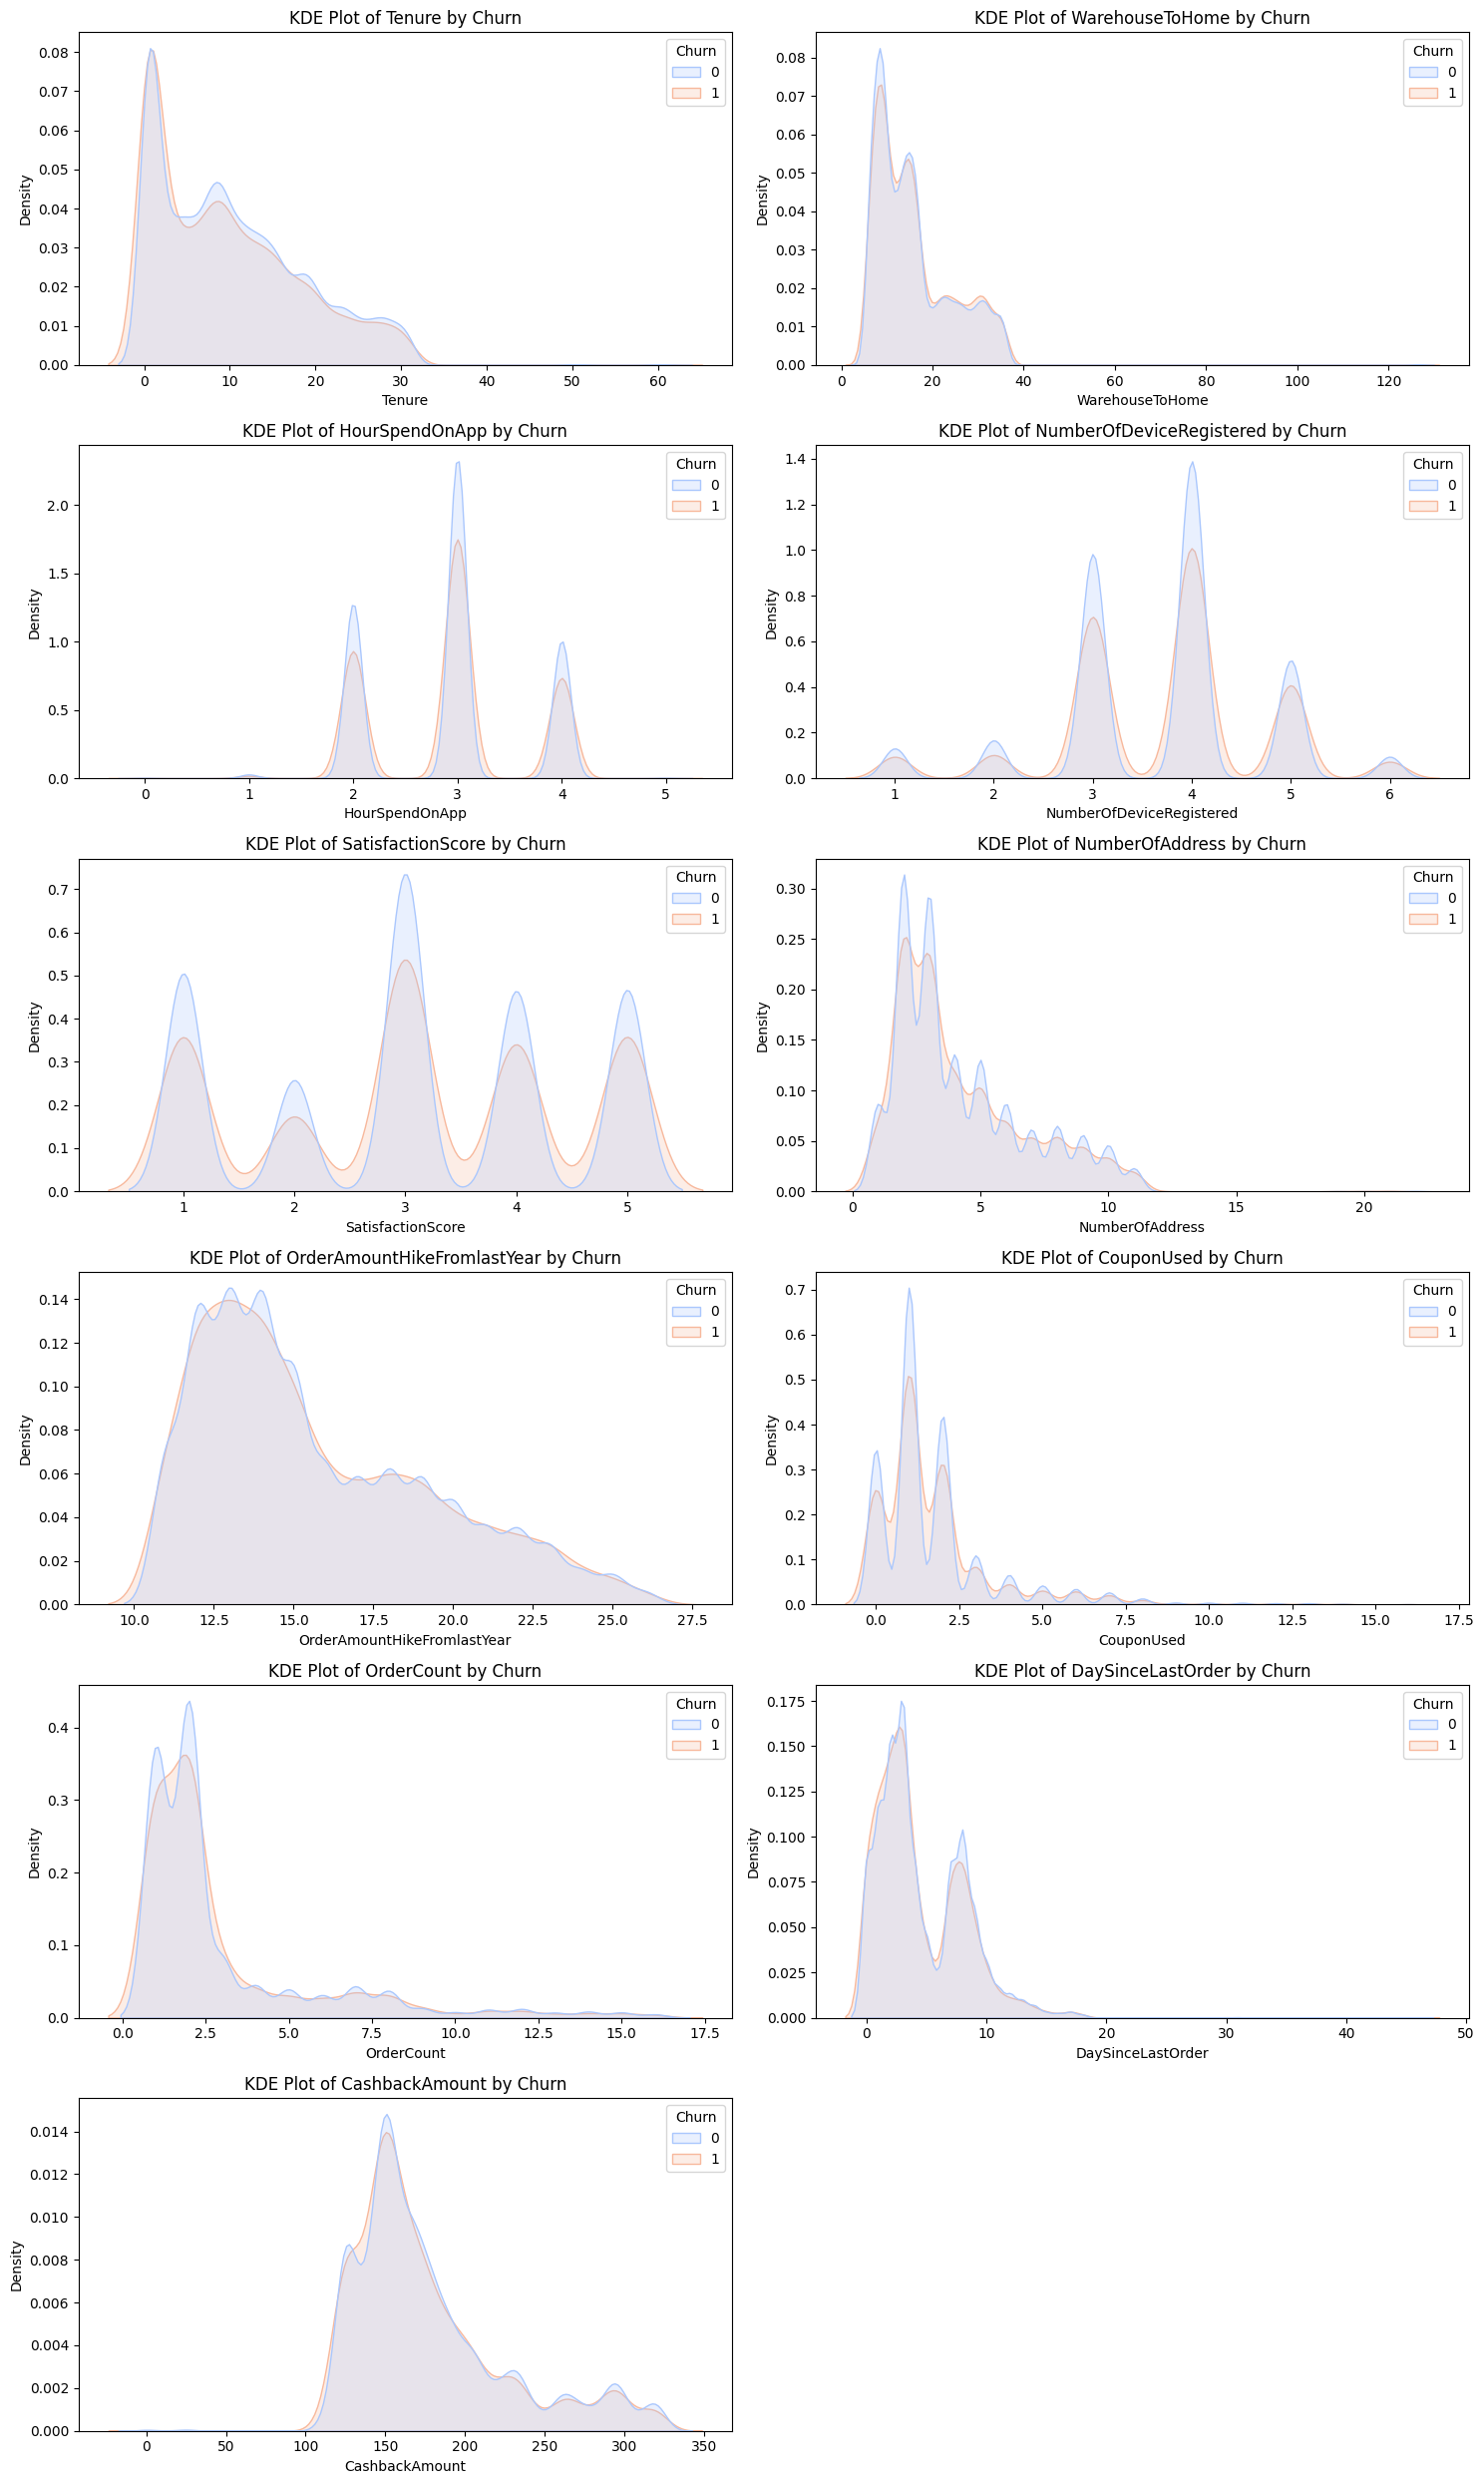

In [51]:



# --- Visualization: KDE Plots (6 rows, 2 columns) ---
kde_numerical_columns = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
                         'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                         'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

plt.figure(figsize=(15, 25))

for i, col in enumerate(kde_numerical_columns):
    plt.subplot(6, 2, i + 1)
    
    # KDE Plot: Shows the full distribution shape to highlight subtle differences
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'KDE Plot of {col} by Churn')

plt.tight_layout()
# Use plt.show() to display the plots directly in the notebook output
plt.show()

In [56]:
categorial_features=['PreferredPaymentMode','PreferedOrderCat','MaritalStatus']

In [57]:
numerical_features=['Tenure','PreferredLoginDevice','CityTier','WarehouseToHome','PreferredPaymentMode','Gender','HourSpendOnApp','NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress','Complain','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder','CashbackAmount']


In [58]:
df_features=df[numerical_features+categorial_features+['Churn']]
df_features.head(10)

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredPaymentMode,PreferedOrderCat,MaritalStatus,Churn
0,4.0,0,3,6.0,Debit Card,1,3.0,3,2,9,1,11.0,1.0,1.0,5.0,159.93,Debit Card,Laptop & Accessory,Single,1
1,9.0,0,1,8.0,UPI,0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,120.90,UPI,Mobile Phone,Single,1
2,9.0,0,1,30.0,Debit Card,0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120.28,Debit Card,Mobile Phone,Single,1
3,0.0,0,3,15.0,Debit Card,0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134.07,Debit Card,Laptop & Accessory,Single,1
4,0.0,0,1,12.0,Credit Card,0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,129.60,Credit Card,Mobile Phone,Single,1
5,0.0,1,1,22.0,Debit Card,1,3.0,5,5,2,1,22.0,4.0,6.0,7.0,139.19,Debit Card,Mobile Phone,Single,1
6,9.0,0,3,11.0,COD,0,2.0,3,2,4,0,14.0,0.0,1.0,0.0,120.86,COD,Laptop & Accessory,Divorced,1
7,9.0,0,1,6.0,Credit Card,0,3.0,3,2,3,1,16.0,2.0,2.0,0.0,122.93,Credit Card,Mobile Phone,Divorced,1
8,13.0,0,3,9.0,E wallet,0,3.0,4,3,2,1,14.0,0.0,1.0,2.0,126.83,E wallet,Mobile Phone,Divorced,1
9,9.0,0,1,31.0,Debit Card,0,2.0,5,3,2,0,12.0,1.0,1.0,1.0,122.93,Debit Card,Mobile Phone,Single,1


# Stepb3:Create features from the data

In [91]:
def train_test_split_and_features(df_features):
    y = df_features["Churn"]
    x = df_features.drop('Churn', axis=1)
    x = pd.get_dummies(x, dtype=int)
    # Note: 'train_test_split' needs to be imported from sklearn.model_selection
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)
    print("X-Features Head:")
    print(x.head(2))
    print("\nTarget Variable Name:", y.name)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test, features

In [92]:
x_train,x_test,y_train,y_test,features=train_test_split_and_features(df_features)

X-Features Head:
   Tenure  PreferredLoginDevice  CityTier  WarehouseToHome  Gender  \
0     4.0                     0         3              6.0       1   
1     9.0                     0         1              8.0       0   

   HourSpendOnApp  NumberOfDeviceRegistered  SatisfactionScore  \
0             3.0                         3                  2   
1             3.0                         4                  3   

   NumberOfAddress  Complain  ...  PreferedOrderCat_Fashion  \
0                9         1  ...                         0   
1                7         1  ...                         0   

   PreferedOrderCat_Footwear  PreferedOrderCat_Grocery  \
0                          0                         0   
1                          0                         0   

   PreferedOrderCat_Laptop & Accessory  PreferedOrderCat_Mobile Phone  \
0                                    1                              0   
1                                    0                        

In [93]:
# Assuming you run this immediately after your function call:
# x_train, x_test, y_train, y_test, features = train_test_split_and_features(df_features)

print("Total Features Created:", len(features))
print("List of Features:")
print(features)

Total Features Created: 37
List of Features:
['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Audio Devices', 'PreferedOrderCat_Books & Stationery', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Footwear', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'PreferedOrderCat_Sports Equipment', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Sin

In [94]:
x_train.head(10)

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferedOrderCat_Fashion,PreferedOrderCat_Footwear,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,PreferedOrderCat_Sports Equipment,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
20330,19.0,0,1,7.0,0,2.0,2,1,3,0,...,0,0,0,0,1,0,0,0,0,1
17532,7.0,1,1,25.0,0,3.0,4,1,2,0,...,0,0,0,1,0,0,0,0,0,1
45819,1.0,0,1,8.0,0,2.0,6,3,3,1,...,0,0,0,0,1,0,0,0,1,0
34807,18.0,0,1,30.0,0,3.0,3,4,2,0,...,0,0,0,1,0,0,0,0,1,0
31888,8.0,0,1,7.0,0,2.0,3,5,2,0,...,0,0,0,1,0,0,0,0,0,1
48372,14.0,0,3,16.0,1,3.0,3,3,1,0,...,0,0,0,1,0,0,0,0,0,1
5524,2.0,1,3,8.0,0,3.0,5,1,3,1,...,0,0,0,1,0,0,0,0,1,0
38032,23.0,0,1,9.0,1,3.0,2,3,10,1,...,0,0,0,1,0,0,0,0,1,0
14944,12.0,0,1,9.0,0,3.0,4,3,7,0,...,1,0,0,0,0,0,0,0,0,1
22793,0.0,0,1,10.0,0,3.0,3,3,2,0,...,1,0,0,0,0,0,0,0,0,1


# Step4:Fit and evaluate model

In [95]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=5, min_samples_split=0.01, max_features=0.8, max_samples=0.8):
    
    # Initialize the RandomForestClassifier model
    random_forest = RandomForestClassifier(
        random_state=0,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        max_samples=max_samples
    )
    
    # Fit the model
    model = random_forest.fit(x_train, y_train)
    
    # Make predictions
    random_forest_predict = random_forest.predict(x_test)
    
    # Calculate metrics
    random_forest_conf_matrix = confusion_matrix(y_test, random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test, random_forest_predict)
    
    # Print results
    print("Confusion Matrix:")
    print(random_forest_conf_matrix)
    print("\n")
    print("Accuracy of Random Forest:", random_forest_acc_score * 100, '%\n')
    print(classification_report(y_test, random_forest_predict))
    
    return model

In [96]:
# Assuming 'df_features' is your final preprocessed DataFrame
# Replace df_features with the actual name of your cleaned dataframe if different
x_train, x_test, y_train, y_test, features = train_test_split_and_features(df_features)

X-Features Head:
   Tenure  PreferredLoginDevice  CityTier  WarehouseToHome  Gender  \
0     4.0                     0         3              6.0       1   
1     9.0                     0         1              8.0       0   

   HourSpendOnApp  NumberOfDeviceRegistered  SatisfactionScore  \
0             3.0                         3                  2   
1             3.0                         4                  3   

   NumberOfAddress  Complain  ...  PreferedOrderCat_Fashion  \
0                9         1  ...                         0   
1                7         1  ...                         0   

   PreferedOrderCat_Footwear  PreferedOrderCat_Grocery  \
0                          0                         0   
1                          0                         0   

   PreferedOrderCat_Laptop & Accessory  PreferedOrderCat_Mobile Phone  \
0                                    1                              0   
1                                    0                        

In [97]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)

Confusion Matrix:
[[8218    0]
 [1782    0]]


Accuracy of Random Forest: 82.17999999999999 %

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      8218
           1       0.00      0.00      0.00      1782

    accuracy                           0.82     10000
   macro avg       0.41      0.50      0.45     10000
weighted avg       0.68      0.82      0.74     10000



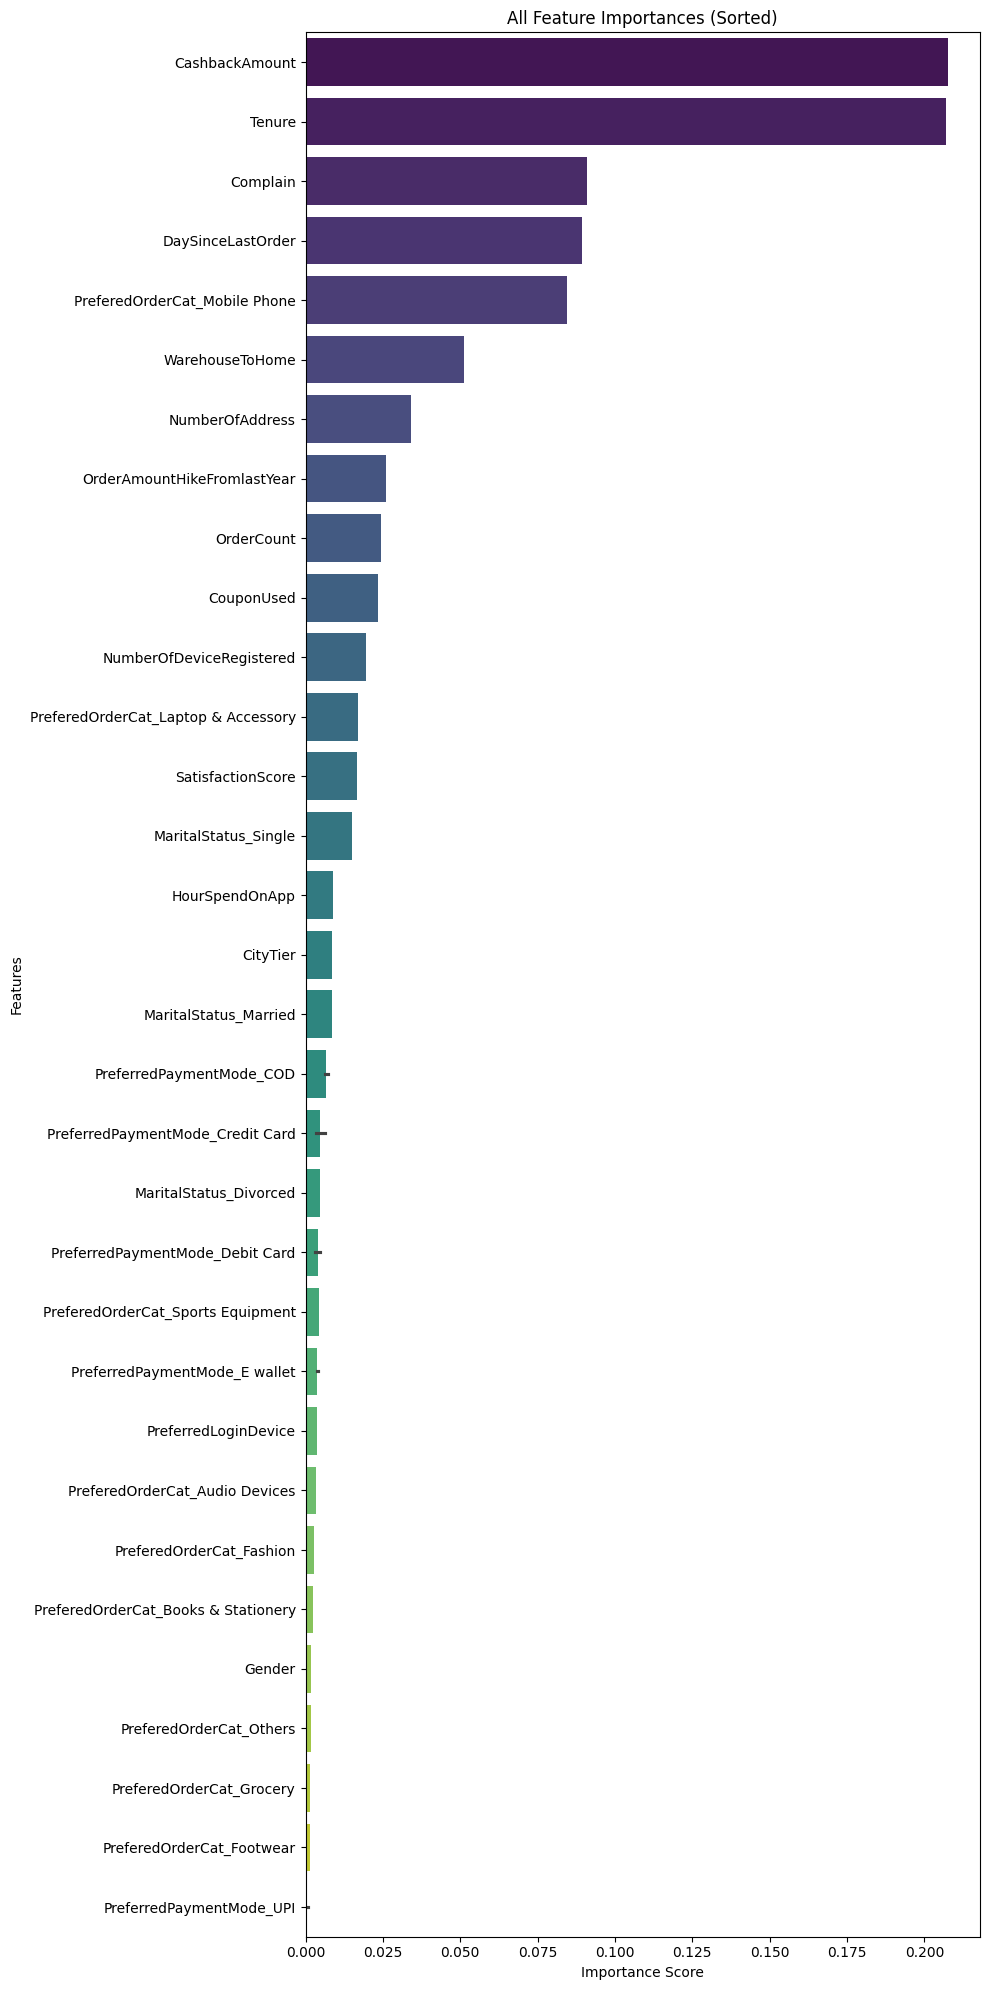

In [99]:
# Assuming 'features' is the list of column names returned by train_test_split_and_features
# And 'model' is the fitted model returned by fit_and_evaluate_model

# 1. Get the feature importance from the model
# This remains the same: it calculates importance for all features and sorts them
feature_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

# 2. Plot ALL features
# Adjusted figsize to be taller to fit all feature names
plt.figure(figsize=(10, 20))

# Removed [:10] to include ALL features in the plot
sns.barplot(x=feature_imp, y=feature_imp.index, palette='viridis')

plt.title("All Feature Importances (Sorted)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [103]:
from xgboost import XGBClassifier
# Also ensure you have the previous imports:
# from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [109]:
def train_test_split_and_features(df_features):
    import pandas as pd
    from sklearn.model_selection import train_test_split # Make sure this is imported/available

    y = df_features["Churn"]
    x = df_features.drop('Churn', axis=1)
    x = pd.get_dummies(x, dtype=int)
    
    # --- ULTIMATE CONVERSION STEP ---
    # Convert the entire DataFrame to a NumPy array. This forces compatible types.
    # The split function will convert the resulting arrays back to DataFrames/Series.
    x_train, x_test, y_train, y_test = train_test_split(
        x.values,   # <-- Pass NumPy array of features
        y.values,   # <-- Pass NumPy array of target
        test_size=0.20,
        random_state=0
    )
    # ---------------------------
    
    # We must redefine x_train and x_test as DataFrames for consistency in subsequent steps (like feature importance)
    # For now, we'll keep them as arrays since the error happens during .fit
    
    print("X_train type after split:", type(x_train))
    print("X_train dtype check:", x_train.dtype)
    
    # Get features list BEFORE converting to array
    features = list(x.columns)
    
    # We will return the NumPy arrays, which should fix the XGBoost error.
    return x_train, x_test, y_train, y_test, features

In [110]:
def fit_and_evaluate_xgboost_model(x_train, x_test, y_train, y_test, max_depth=5, learning_rate=0.1, n_estimators=100):
    
    # Initialize the XGBClassifier model
    # Note: use_label_encoder=False and eval_metric='logloss' are added to suppress common warnings
    xgboost_model = XGBClassifier(
        random_state=0,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    # Fit the model to the training data
    model = xgboost_model.fit(x_train, y_train)
    
    # Make predictions
    xgboost_predict = xgboost_model.predict(x_test)
    
    # Calculate confusion matrix and accuracy score
    xgboost_conf_matrix = confusion_matrix(y_test, xgboost_predict)
    xgboost_acc_score = accuracy_score(y_test, xgboost_predict)
    
    # Print the evaluation results
    print("Confusion Matrix:")
    print(xgboost_conf_matrix)
    print("\n")
    print("Accuracy of XGBoost:", xgboost_acc_score * 100, '%\n')
    print(classification_report(y_test, xgboost_predict))
    
    return model

In [111]:
x_train, x_test, y_train, y_test, features = train_test_split_and_features(df_features)

X_train type after split: <class 'numpy.ndarray'>
X_train dtype check: float64


In [112]:
model_xgb = fit_and_evaluate_xgboost_model(x_train, x_test, y_train, y_test)

Confusion Matrix:
[[8213    5]
 [1754   28]]


Accuracy of XGBoost: 82.41000000000001 %

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      8218
           1       0.85      0.02      0.03      1782

    accuracy                           0.82     10000
   macro avg       0.84      0.51      0.47     10000
weighted avg       0.83      0.82      0.75     10000



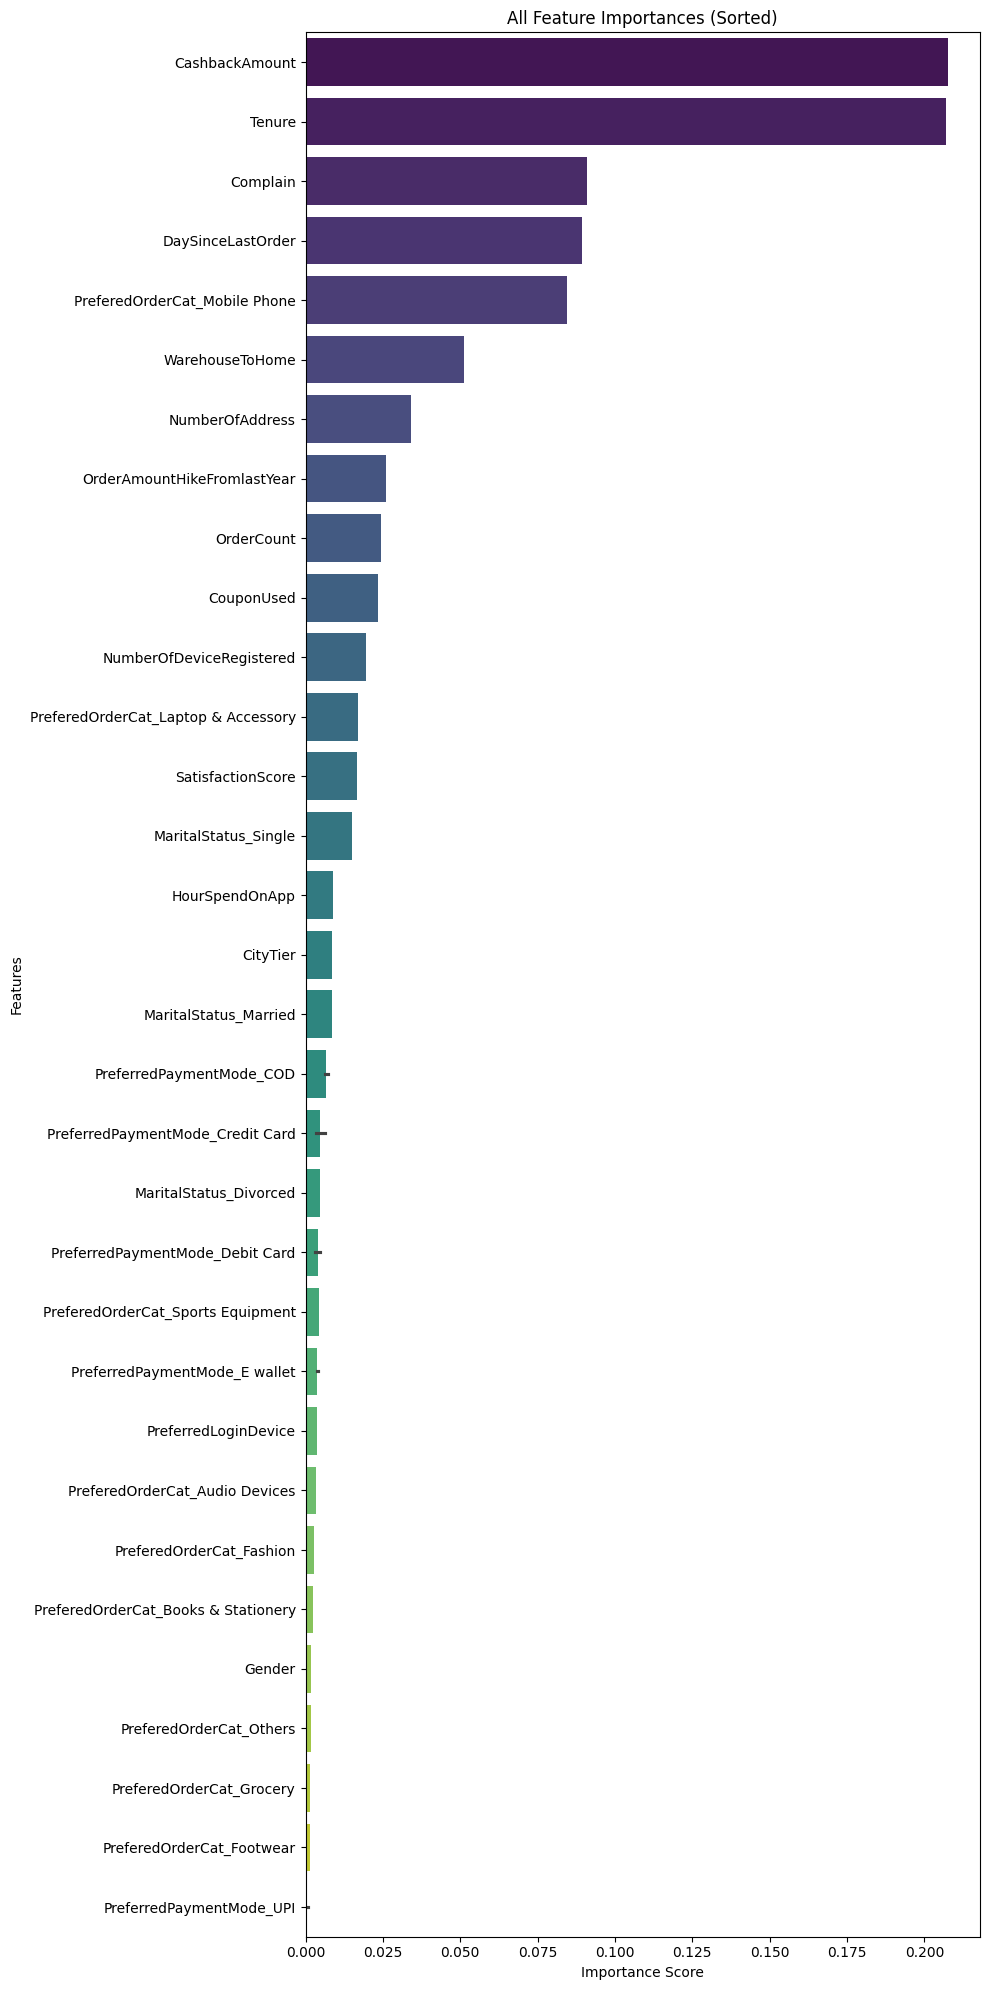

In [113]:
# Assuming 'features' is the list of column names returned by train_test_split_and_features
# And 'model' is the fitted model returned by fit_and_evaluate_model

# 1. Get the feature importance from the model
# This remains the same: it calculates importance for all features and sorts them
feature_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

# 2. Plot ALL features
# Adjusted figsize to be taller to fit all feature names
plt.figure(figsize=(10, 20))

# Removed [:10] to include ALL features in the plot
sns.barplot(x=feature_imp, y=feature_imp.index, palette='viridis')

plt.title("All Feature Importances (Sorted)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 2. Code for Hyperparameter Tuning

In [114]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, make_scorer

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [3, 5, 7],      # Tree depth
    'learning_rate': [0.1, 0.01],# Step size
    'gamma': [0, 0.1]            # Minimum loss reduction for a split
}

# Initialize the XGBoost model
# use_label_encoder=False and eval_metric='logloss' are for suppressing warnings
xgb_base = XGBClassifier(
    random_state=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Initialize GridSearchCV
# scoring='accuracy' tells the grid search to maximize accuracy
# cv=3 uses 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=3, # Shows progress
    n_jobs=-1  # Uses all available CPU cores for efficiency
)

# Run the grid search on the training data
# NOTE: x_train and y_train must be NumPy arrays/Series compatible with the fix discussed previously!
grid_search.fit(x_train, y_train) 

# --- After fitting, check the best parameters and score ---
print("Best parameters found on the training set:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy score:")
print(grid_search.best_score_ * 100)

# --- Evaluate the final best model on the test set ---
best_xgb_model = grid_search.best_estimator_
final_predictions = best_xgb_model.predict(x_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print("\nFinal Test Accuracy of the Tuned Model:")
print(f"{final_accuracy * 100:.4f} %")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters found on the training set:
{'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

Best cross-validation accuracy score:
83.41250116673645

Final Test Accuracy of the Tuned Model:
82.6500 %
